# Steane Basic Level Noise (single round)

Data generation and analysis
    + different decoder: ML, MWPM
    + different distances
    + different noise levels

analysis: 
    + show asymptotic behavior
    + determine thresholds


In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tools.file import write_config, smart_read_folder 
from tools.combined import generate_new_data_from_config_file
from tools.analysis import data_pre_processing, determine_threshold, data_plot_log_error_rates, data_plot_fssa_results

## Config Defintions and Data Generation

Steane circ (order 0p) with only 1 QEC round (both log X and Z observable)

Basic noise with different noise levels

Decoding both in ML and MWPM


In [18]:
# General parameter
noise_rates = [float(x) for x in np.logspace(-1.4,-0.8,dtype=float)] # weird choice of noise rate because i need to put it into a yaml file -> might be probelmatic later!
distances = [3,5,7,9,11,13,15] # 3 is newly included! not yet in data!
qec_rounds = [1,]
order = "0p"
circuit_type = "steane"

# Main parameters
num_shots_ML = 5_000
decoder_type_ML = "ml_test"

# Z config
noise_model = "bit_flip"
observable  = "Z"
init_state = "0"

# ML configurations parameters
# numpy data types:
data_types = [64, 32]

# decoder func string  
decode_strs = ["basic", "log", "aron"]




In [19]:
# Folder names (for writing data to file):
name = "ml_test"

In [20]:
# Switches for data generation
regen_data_ML = False 

In [21]:
# ML Config (Z)
# Verbose is better!
for decode_str in decode_strs:
    for data_type in data_types: 
        name = "ml_test_" + decode_str + "_" + str(data_type) 
        config_ML = {
            "circuit": {
                "distances":    distances, 
                "qec_rounds":   qec_rounds, 
                "observable":   observable,   
                # not yet implemented
                "order":        order, 
                "type":         circuit_type, 
                # redundant:
                "inital_state": init_state,
                "special_parameter": {},
            },
            "noise_model": {
                "type":         noise_model,
                "noise_rates":  noise_rates,
                "special_parameter": {},        # open for future references
            },
            "decoder": {
                "type":         decoder_type_ML, 
                "special_parameter": {
                    "data_type": data_type,
                    "decode_str": decode_str,
                },        # open for future references
            },
            "sampling": {
                "num_shots":    num_shots_ML,       # number of shots per configuration
            },
        }
                
        # write config to file
        config_path = write_config(config_ML, name, backup=True, sub_name="config" )

        # Generate ML Data
        if regen_data_ML or False:
            generate_new_data_from_config_file(config_path, output_folder_name = name)
        if decode_str == "aron":
            break

## Analysis

[toric code](https://errorcorrectionzoo.org/c/toric):

+ toric code: code capacity 
    + MWPM: px = 10.31%
    + ML: 10.94 +- 0.02%

[surface code](https://errorcorrectionzoo.org/c/surface):

[arthur pesah](https://arthurpesah.me/blog/2023-05-13-surface-code/):





In [22]:
# Folder paths (reading in data)
# basic config is given to be able to infer the correct path to the data!
# r_folder_name_ML_Z = "md_1r_mp_BN"
# basic_config_ML_Z = config_ML_Z

# r_folder_name_ML_X = "md_1r_mp_BN"
# basic_config_ML_X = config_ML_X

# r_folder_name_MWPM_Z = "md_1r_mp_BN"
# basic_config_MWPM_Z = config_MWPM_Z

# r_folder_name_MWPM_X = "md_1r_mp_BN"
# basic_config_MWPM_X = config_MWPM_X

r_folder_name_ML_aron = "/home/fu494742/MasterArbeit/code/data/steane/0p/bit_flip/ml_test/z/ml_test_aron_64" 
r_folder_name_ML_basic_32 = "/home/fu494742/MasterArbeit/code/data/steane/0p/bit_flip/ml_test/z/ml_test_basic_32" 
r_folder_name_ML_basic_64 = "/home/fu494742/MasterArbeit/code/data/steane/0p/bit_flip/ml_test/z/ml_test_basic_64" 
r_folder_name_ML_log_32 = "/home/fu494742/MasterArbeit/code/data/steane/0p/bit_flip/ml_test/z/ml_test_log_32" 
r_folder_name_ML_log_64 = "/home/fu494742/MasterArbeit/code/data/steane/0p/bit_flip/ml_test/z/ml_test_log_64"

lit_p_th_ml = 0.1094
lit_p_th_mwpm = 0.1031

In [23]:
def analysis_pipeline(
        folder_path, 
        guess_pth, 
        guess_nu, 
        min_distance: list = None, 
        max_distance: list = None, 
        min_noise_rate: list = None,
        max_noise_rate: list = None,
        p_window: list = None,
        plots = True,
        title_part: str = "",
        filename_part: str = "",
        ):

    if p_window != None:
        if min_noise_rate != None or max_noise_rate != None:
            raise UserWarning("Both p_window and min-/max_noise_rate give! Too much restictions!")
        min_noise_rate = np.array(guess_pth) / p_window
        max_noise_rate = np.array(guess_pth) * p_window

    config, data = smart_read_folder(folder_path=folder_path)
    print(f"Num_shots: {data["num_shots"]}")

    data = data_pre_processing(data)
    data = determine_threshold(
        data,
        guess_nu=guess_nu,
        guess_pth=guess_pth,
        min_distance=min_distance,
        max_distance=max_distance,
        min_noise_rate=min_noise_rate,
        max_noise_rate=max_noise_rate,
        )
    # complete
    if plots:
        if filename_part !="":
            filename_er_c = filename_part + "_log_error_rate_complete" 
            filename_fssa = filename_part + "_fssa" 
            filename_er_fssa = filename_part + "_log_error_rate_fssa" 
            filename_er_zoom = filename_part + "_log_error_rate_zoom" 
        else:
            filename_default = ""
            filename_er_c = filename_default 
            filename_fssa = filename_default 
            filename_er_fssa = filename_default 
            filename_er_zoom = filename_default 
        if title_part !="":
            title_er_c = title_part + ""
            title_fssa = title_part + ": Data collapse method"
            title_er_fssa = title_part + ": FSSA interval"
            title_er_zoom = title_part + ": Zoomed in"
        else:
            title_default = ""
            title_er_c = title_default
            title_fssa = title_default
            title_er_fssa = title_default
            title_er_zoom = title_default

        data_plot_log_error_rates(
            data,
            filename=filename_er_c,
            title=title_er_c,
            )
        data_plot_fssa_results(
            data,
            min_distance=min_distance,
            max_distance=max_distance,
            min_noise_rate=min_noise_rate,
            max_noise_rate=max_noise_rate,
            filename=filename_fssa,
            title=title_fssa,
            )
        # around threshold
        data_plot_log_error_rates(
            data,
            min_distance=min_distance,
            max_distance=max_distance,
            min_noise_rate=min_noise_rate,
            max_noise_rate=max_noise_rate,
            filename=filename_er_fssa,
            title=title_er_fssa,
        )
          
        idx = np.argmax(data["noise_rates"] > data["p_th"])
        idx_window = 3
        min_noise_rate_zoom =[data["noise_rates"][idx-idx_window] ]
        max_noise_rate_zoom =[data["noise_rates"][idx+idx_window] ]

        data_plot_log_error_rates(
            data,
            min_distance=min_distance,
            max_distance=max_distance,
            min_noise_rate=min_noise_rate_zoom,
            max_noise_rate=max_noise_rate_zoom,
            filename=filename_er_zoom,
            title=title_er_zoom,
        )
    print(f"p_th: {data["p_th"]}")
    print(f"nu_fit: {data["nu_fit"]}")
    return data

### Generate analysis Data

In [24]:
# General fit parameters: 
g_pth_ml = [0.109]
g_pth_mwpm = [0.103]

g_nu = [1.5]

p_window = [10**(0.1)]
min_distance = [5]

Num_shots: 85000

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 84.98486290384336
             x: [ 1.039e-01  7.544e-01]
           nit: 55
          nfev: 105
 final_simplex: (array([[ 1.039e-01,  7.544e-01],
                       [ 1.039e-01,  7.544e-01],
                       [ 1.039e-01,  7.544e-01]]), array([ 8.498e+01,  8.498e+01,  8.498e+01]))


<Figure size 640x480 with 0 Axes>

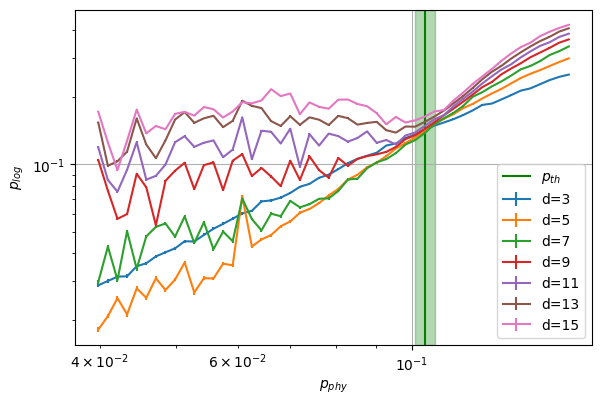

<Figure size 640x480 with 0 Axes>

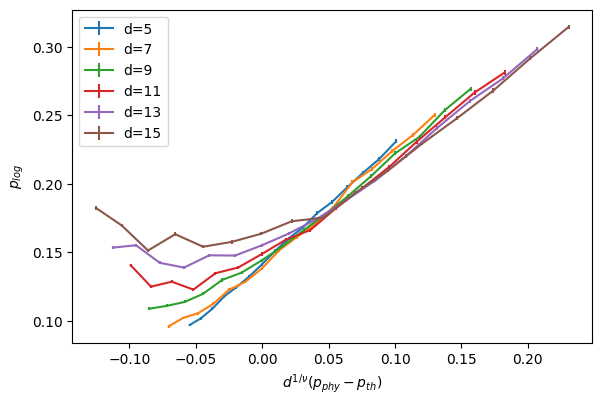

<Figure size 640x480 with 0 Axes>

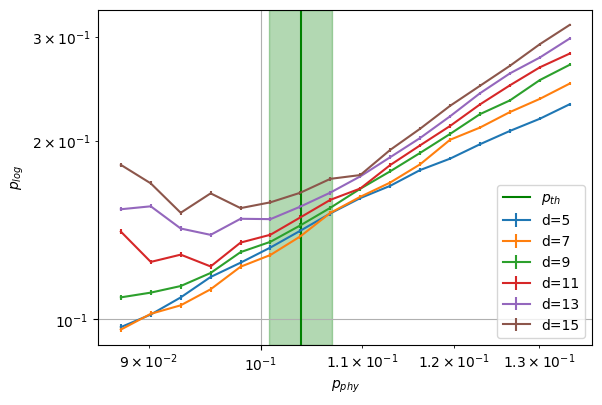

<Figure size 640x480 with 0 Axes>

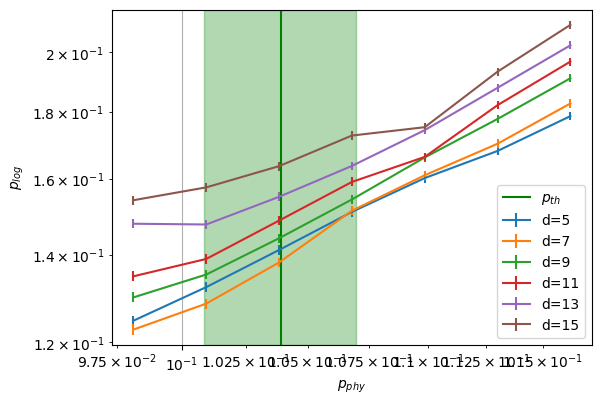

p_th: [0.1039083]
nu_fit: [1.32557323]


In [25]:
result = analysis_pipeline(
    folder_path=    r_folder_name_ML_basic_32,
    guess_pth =     g_pth_ml,
    guess_nu =      g_nu,
    min_distance=   min_distance, 
    p_window =      p_window,
    )

result_basic_32 = result

Num_shots: 65000

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.9987479532787811
             x: [ 1.082e-01  6.615e-01]
           nit: 51
          nfev: 101
 final_simplex: (array([[ 1.082e-01,  6.615e-01],
                       [ 1.082e-01,  6.615e-01],
                       [ 1.082e-01,  6.615e-01]]), array([ 9.987e-01,  9.987e-01,  9.988e-01]))


<Figure size 640x480 with 0 Axes>

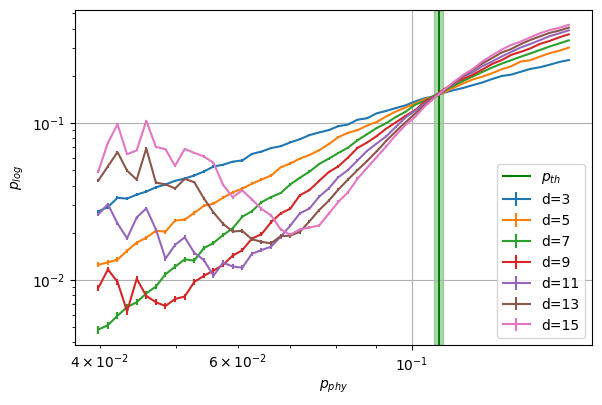

<Figure size 640x480 with 0 Axes>

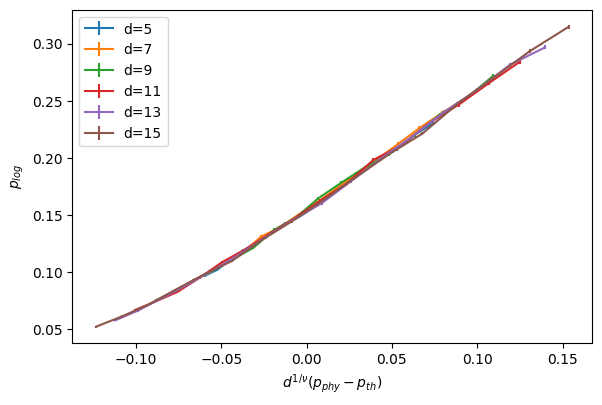

<Figure size 640x480 with 0 Axes>

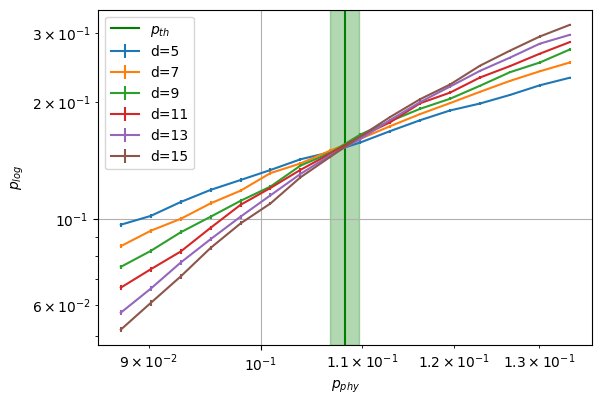

<Figure size 640x480 with 0 Axes>

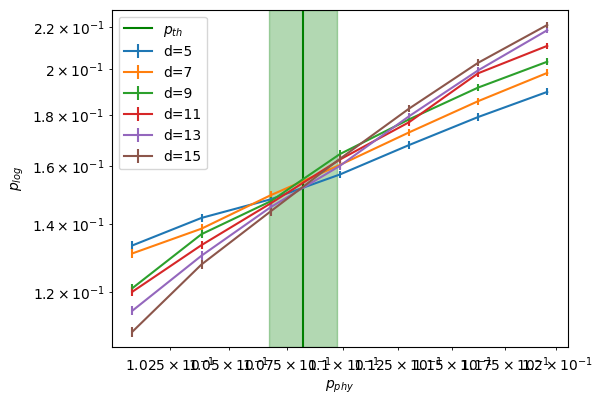

p_th: [0.10823398]
nu_fit: [1.51173435]


In [26]:
result = analysis_pipeline(
    folder_path=    r_folder_name_ML_basic_64,
    guess_pth =     g_pth_ml,
    guess_nu =      g_nu,
    min_distance=   min_distance, 
    p_window =      p_window,
    )
result_basic_64 = result

Num_shots: 60000

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 65.08778076418912
             x: [ 1.010e-01  7.331e-01]
           nit: 38
          nfev: 80
 final_simplex: (array([[ 1.010e-01,  7.331e-01],
                       [ 1.010e-01,  7.331e-01],
                       [ 1.010e-01,  7.331e-01]]), array([ 6.509e+01,  6.509e+01,  6.509e+01]))


<Figure size 640x480 with 0 Axes>

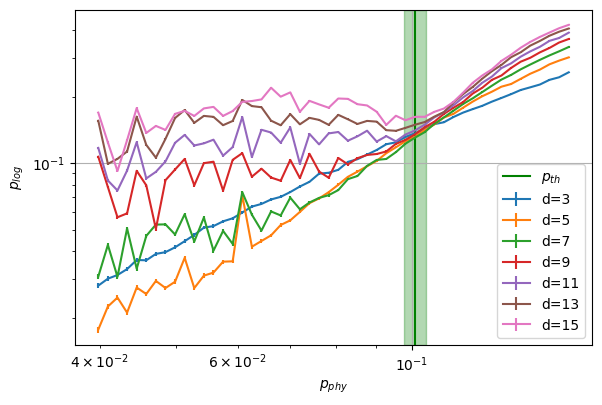

<Figure size 640x480 with 0 Axes>

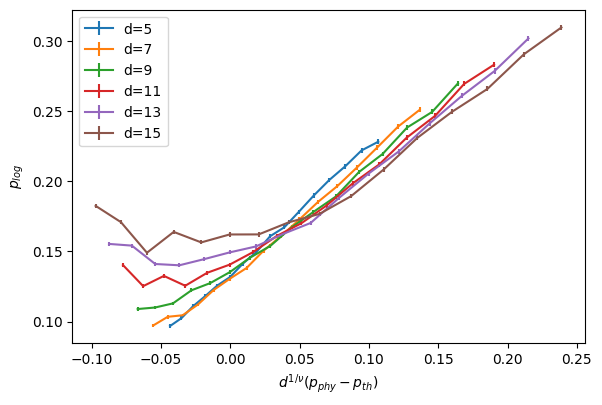

<Figure size 640x480 with 0 Axes>

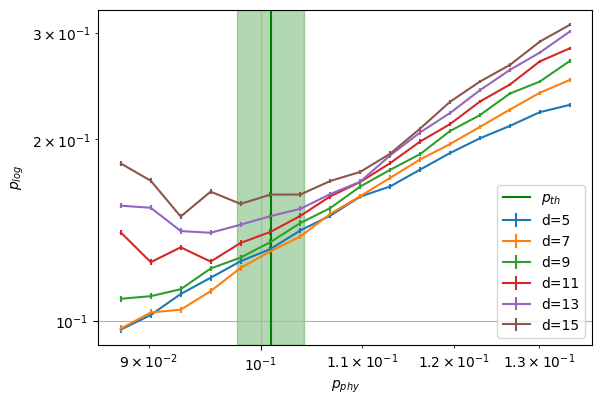

<Figure size 640x480 with 0 Axes>

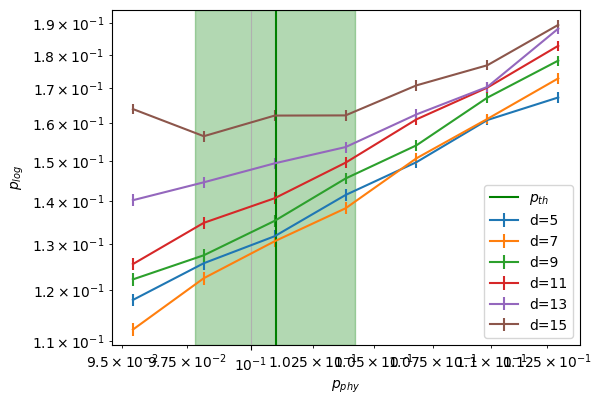

p_th: [0.10101448]
nu_fit: [1.36415745]


In [27]:
result = analysis_pipeline(
    folder_path=    r_folder_name_ML_log_32,
    guess_pth =     g_pth_ml,
    guess_nu =      g_nu,
    min_distance=   min_distance, 
    p_window =      p_window,
    )

result_log_32 = result

Num_shots: 100000

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.9636608260186986
             x: [ 1.082e-01  6.438e-01]
           nit: 64
          nfev: 123
 final_simplex: (array([[ 1.082e-01,  6.438e-01],
                       [ 1.082e-01,  6.438e-01],
                       [ 1.082e-01,  6.438e-01]]), array([ 9.637e-01,  9.637e-01,  9.637e-01]))


<Figure size 640x480 with 0 Axes>

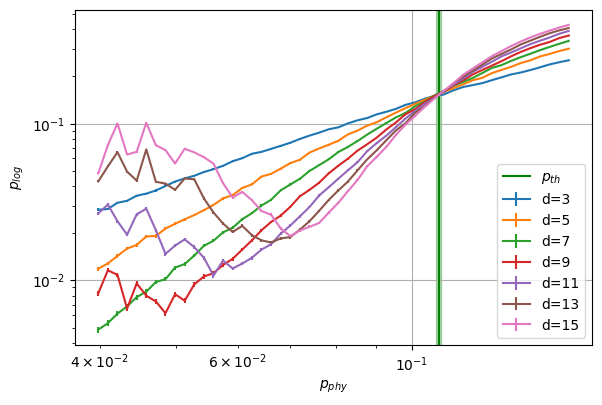

<Figure size 640x480 with 0 Axes>

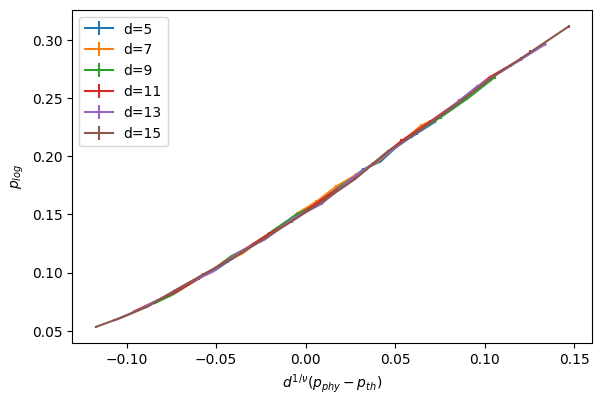

<Figure size 640x480 with 0 Axes>

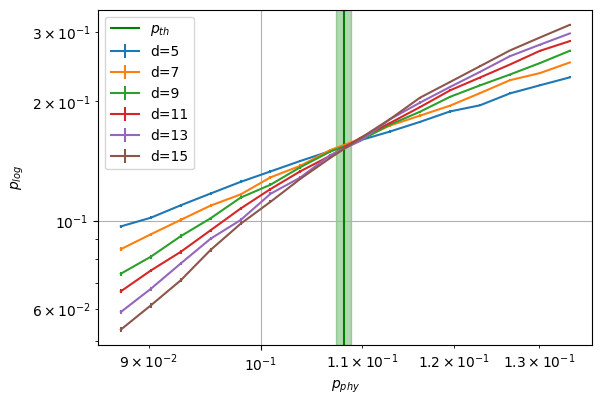

<Figure size 640x480 with 0 Axes>

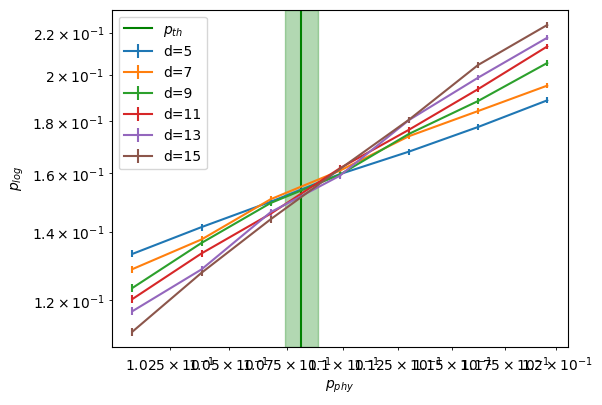

p_th: [0.10815089]
nu_fit: [1.55321551]


In [28]:
result = analysis_pipeline(
    folder_path=    r_folder_name_ML_log_64,
    guess_pth =     g_pth_ml,
    guess_nu =      g_nu,
    min_distance=   min_distance, 
    p_window =      p_window,
    )
result_log_64 = result

Num_shots: 100000

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.8304154479268224
             x: [ 1.081e-01  6.558e-01]
           nit: 58
          nfev: 110
 final_simplex: (array([[ 1.081e-01,  6.558e-01],
                       [ 1.081e-01,  6.558e-01],
                       [ 1.081e-01,  6.558e-01]]), array([ 8.304e-01,  8.304e-01,  8.304e-01]))


<Figure size 640x480 with 0 Axes>

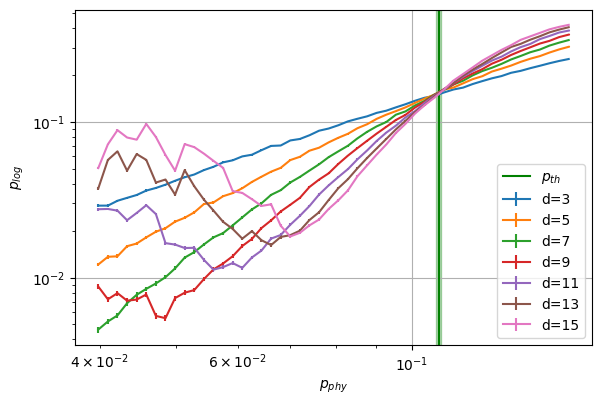

<Figure size 640x480 with 0 Axes>

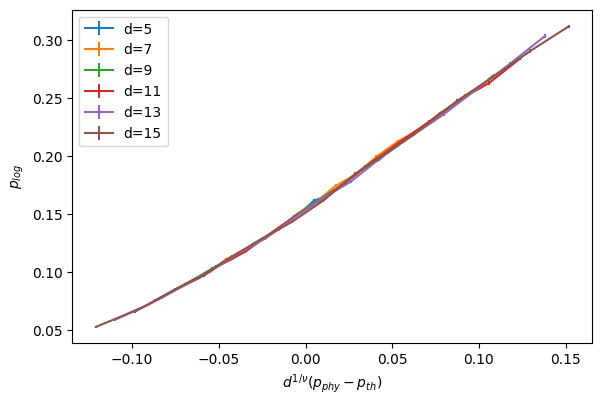

<Figure size 640x480 with 0 Axes>

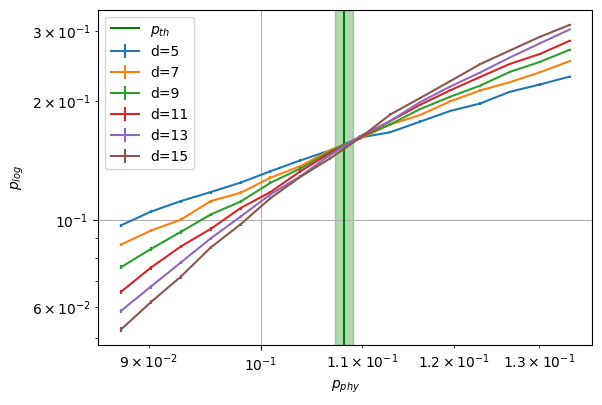

<Figure size 640x480 with 0 Axes>

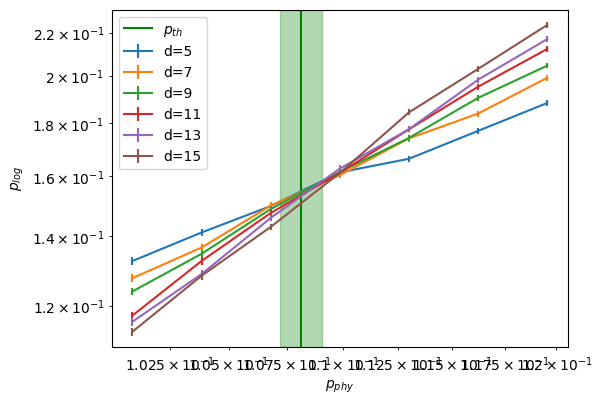

p_th: [0.10814163]
nu_fit: [1.52477658]


In [29]:
# ML Z
result = analysis_pipeline(
    folder_path=    r_folder_name_ML_aron,
    guess_pth =     g_pth_ml,
    guess_nu =      g_nu,
    min_distance=   min_distance, 
    p_window =      p_window,
    )
result_aron = result


In [30]:
results = [result_basic_32, result_basic_64, result_log_32, result_log_64, result_aron]
title = ["basic 32", "basic 64", "log 32", "log 64", "aron"]

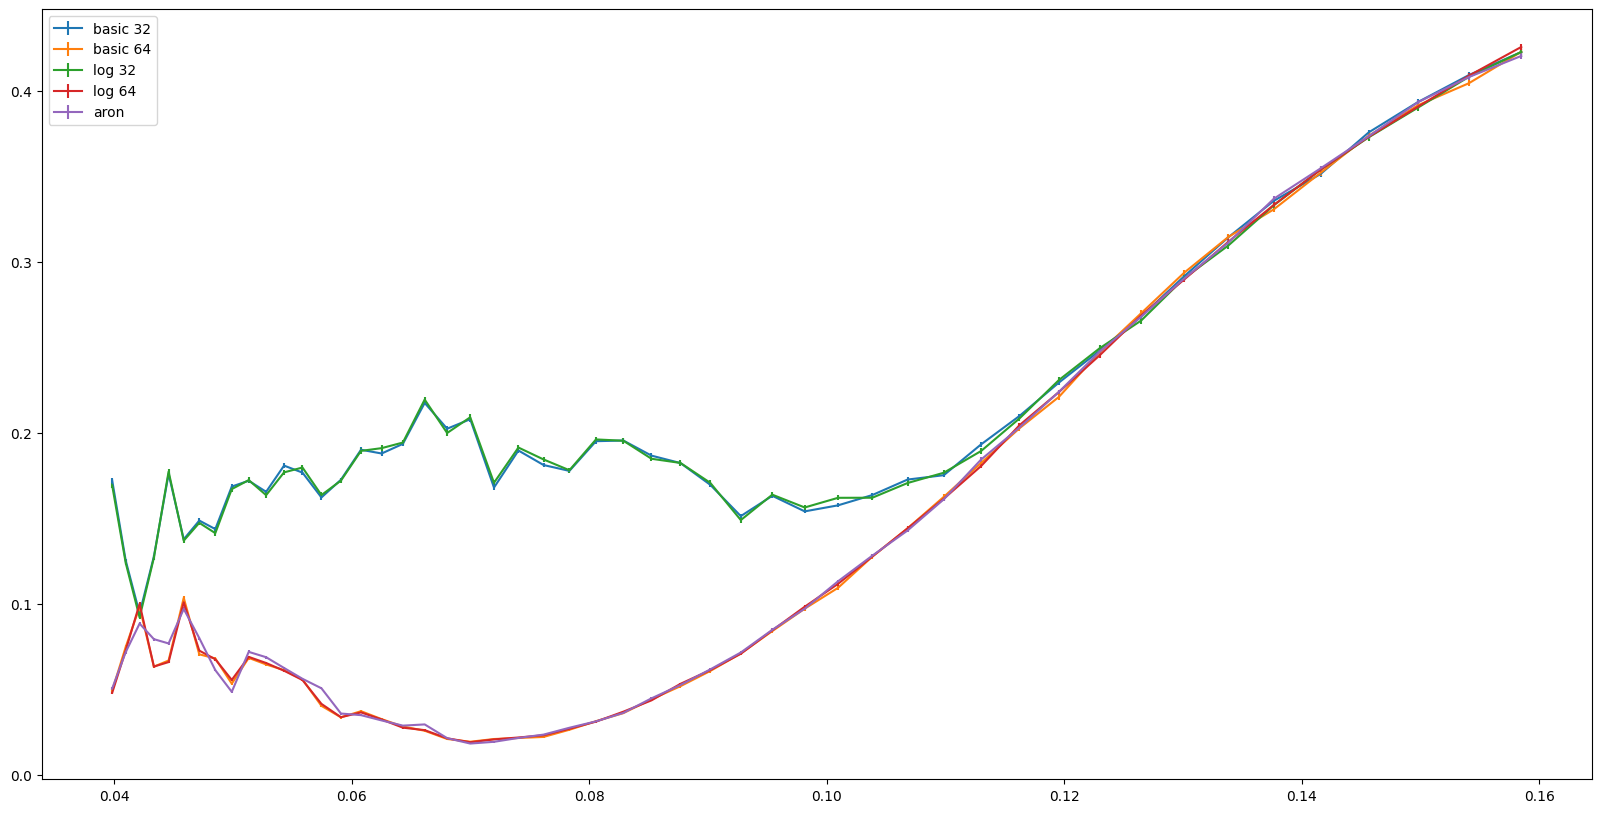

In [36]:
d_id = -1
plt.figure(figsize=(20,10))
for i,result in enumerate(results):
    plt.errorbar(
        result["noise_rates"],
        result["log_error_rates"][d_id][0],
        yerr=result["err_log_error_rates"][d_id][0],
        label=title[i],
        )
plt.legend()
plt.show()